In [2]:
import numpy as np
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import os

# Calculate dates
end_date = datetime(2024, 12, 6)
start_date = datetime(2000, 12, 18)  # 24 years ago

# Download SPX data
# Check if data file exists
if os.path.exists('spx_data.csv'):
    # Import existing data
    spx = pd.read_csv('spx_data.csv', index_col='Date', parse_dates=True)
    print("Data loaded from existing CSV file")
    print(f"Total rows: {len(spx)}")
    print("\nLast few rows of the data:")
    print(spx.tail())
else:
    # Download and save data if file doesn't exist
    spx = yf.download('^GSPC', start=start_date, end=end_date)
    spx.to_csv('spx_data.csv')
    print(f"Data downloaded from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
    print(f"Total rows: {len(spx)}")
    print("\nLast few rows of the data:")
    print(spx.tail())



Data loaded from existing CSV file
Total rows: 6029

Last few rows of the data:
                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2024-11-29  6003.979980  6044.169922  6003.979980  6032.379883  6032.379883   
2024-12-02  6040.109863  6053.580078  6035.330078  6047.149902  6047.149902   
2024-12-03  6042.970215  6052.069824  6033.390137  6049.879883  6049.879883   
2024-12-04  6069.390137  6089.839844  6061.060059  6086.490234  6086.490234   
2024-12-05  6089.029785  6094.549805  6072.899902  6075.109863  6075.109863   

                Volume  
Date                    
2024-11-29  2444420000  
2024-12-02  4412470000  
2024-12-03  4095000000  
2024-12-04  4003390000  
2024-12-05  4212020000  



Summary statistics of daily returns:
count    6028.000000
mean        0.000253
std         0.012167
min        -0.127652
25%        -0.004609
50%         0.000674
75%         0.005834
max         0.109572
Name: Returns, dtype: float64

First few daily returns:
Date
2000-12-18         NaN
2000-12-19   -0.013043
2000-12-20   -0.031796
2000-12-21    0.007970
2000-12-22    0.024094
Name: Returns, dtype: float64


Matplotlib is building the font cache; this may take a moment.


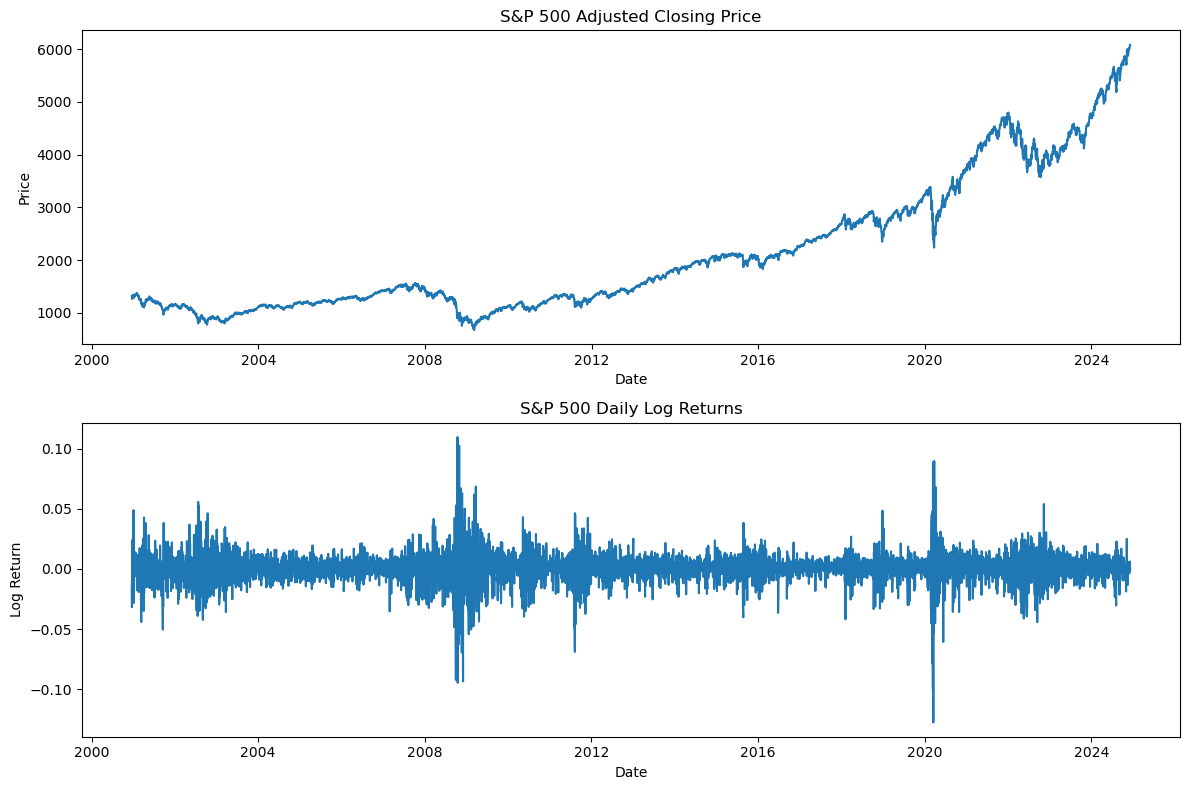

In [3]:
# Calculate log daily returns
# Use adjusted close price to account for dividends and splits
spx['Returns'] = np.log(spx['Adj Close'] / spx['Adj Close'].shift(1))

# Display summary statistics of returns
print("\nSummary statistics of daily returns:")
print(spx['Returns'].describe())

# Display first few returns
print("\nFirst few daily returns:")
print(spx['Returns'].head())

import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot adjusted closing prices
ax1.plot(spx.index.to_numpy(), spx['Adj Close'].to_numpy())
ax1.set_title('S&P 500 Adjusted Closing Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.grid(False)

# Plot returns
ax2.plot(spx.index.to_numpy(), spx['Returns'].to_numpy())
ax2.set_title('S&P 500 Daily Log Returns')
ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.grid(False)


# Increase spacing between subplots
plt.subplots_adjust(hspace=0.3)

# Save the plot to PDF
plt.savefig('spx_plot.pdf', format='pdf')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()




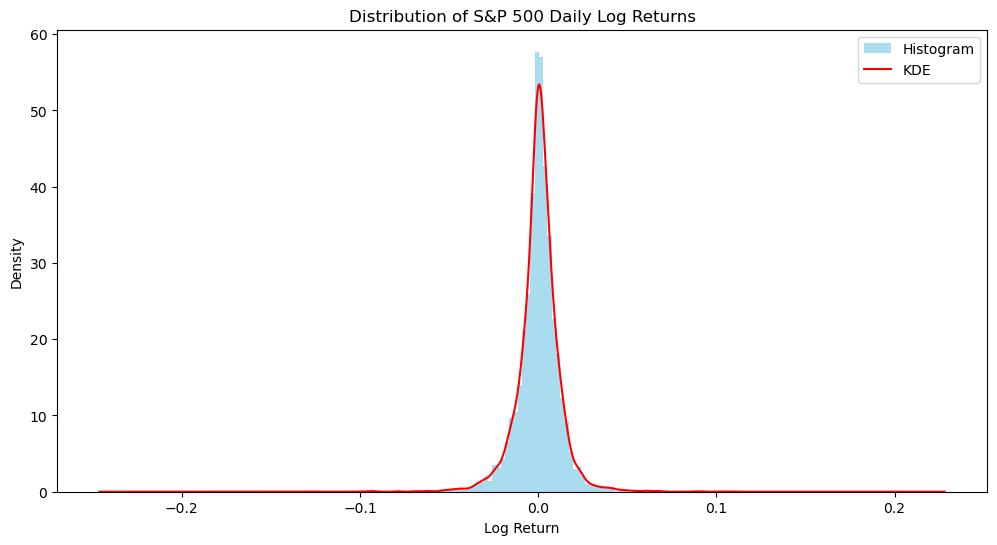


Key Statistics of S&P 500 Daily Log Returns:
-------------------------------------------
                      Value
Mean                 0.0003
Median               0.0007
Standard Deviation   0.0122
Skewness            -0.4077
Kurtosis            10.9822
Minimum             -0.1277
Maximum              0.1096


In [4]:
# Create histogram with kernel density estimation
plt.figure(figsize=(12, 6))
plt.hist(spx['Returns'].dropna(), bins=100, density=True, alpha=0.7, color='skyblue', label='Histogram')
spx['Returns'].dropna().plot.kde(color='red', label='KDE')
plt.title('Distribution of S&P 500 Daily Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Density')
plt.legend()
plt.grid(False)

# Save the plot
plt.savefig('spx_returns_dist.pdf', format='pdf')
plt.show()


# Calculate and display key statistics
stats = {
    'Mean': spx['Returns'].mean(),
    'Median': spx['Returns'].median(),
    'Standard Deviation': spx['Returns'].std(),
    'Skewness': spx['Returns'].skew(),
    'Kurtosis': spx['Returns'].kurtosis(),
    'Minimum': spx['Returns'].min(),
    'Maximum': spx['Returns'].max()
}

# Create a DataFrame for nice display
stats_df = pd.DataFrame.from_dict(stats, orient='index', columns=['Value'])
stats_df = stats_df.round(4)

print("\nKey Statistics of S&P 500 Daily Log Returns:")
print("-------------------------------------------")
print(stats_df)


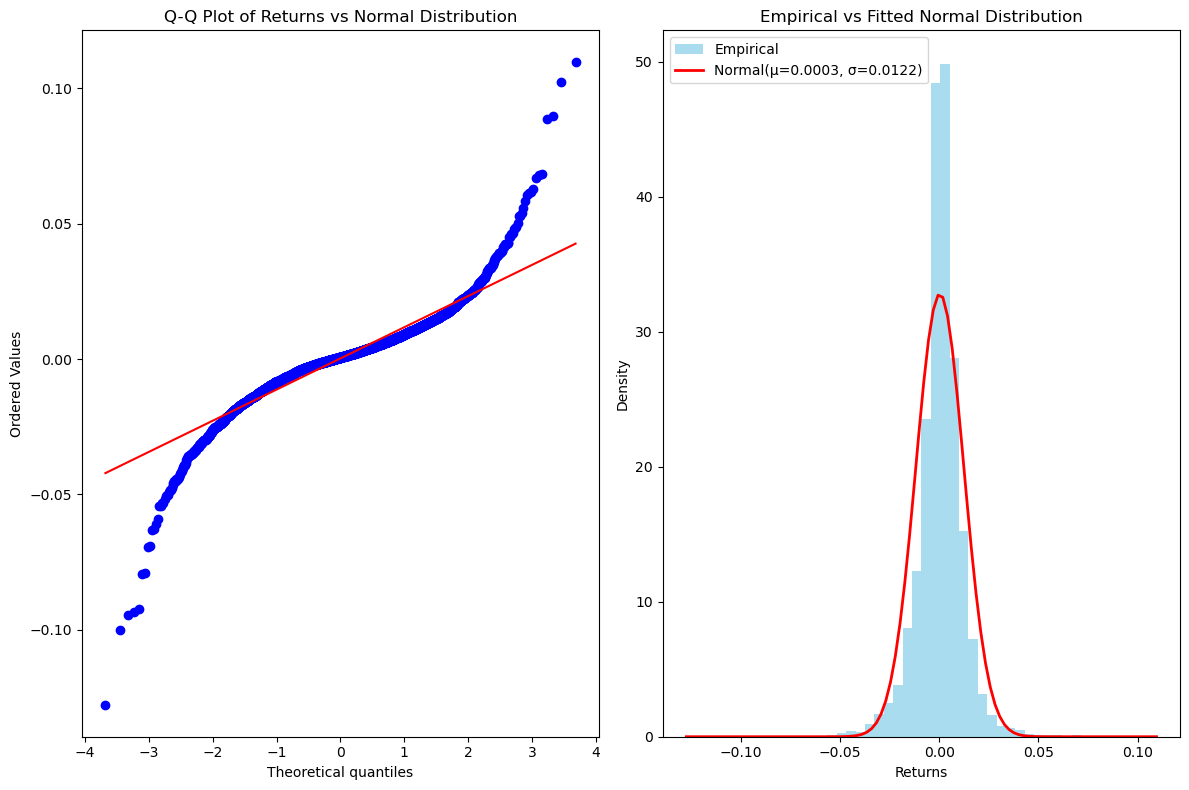


Shapiro-Wilk Test for Normality:
Statistic: 0.8946
p-value: 1.5279e-53


/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6028.
  res = hypotest_fun_out(*samples, **kwds)


In [5]:
# Fit Normal Distribution and Check Goodness of Fit
import scipy.stats as stats

# Fit normal distribution to returns
mu, sigma = stats.norm.fit(spx['Returns'].dropna())

# Create Q-Q plot
plt.figure(figsize=(12, 8))

# Left subplot: Q-Q plot
plt.subplot(1, 2, 1)
stats.probplot(spx['Returns'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot of Returns vs Normal Distribution')

# Right subplot: Compare fitted normal with empirical distribution
plt.subplot(1, 2, 2)
x = np.linspace(spx['Returns'].min(), spx['Returns'].max(), 100)
plt.hist(spx['Returns'].dropna(), bins=50, density=True, alpha=0.7, color='skyblue', label='Empirical')
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'Normal(μ={mu:.4f}, σ={sigma:.4f})')
plt.title('Empirical vs Fitted Normal Distribution')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.savefig('spx_normal_fit.pdf', format='pdf')
plt.show()

# Perform Shapiro-Wilk test for normality
stat, p_value = stats.shapiro(spx['Returns'].dropna())
print("\nShapiro-Wilk Test for Normality:")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4e}")

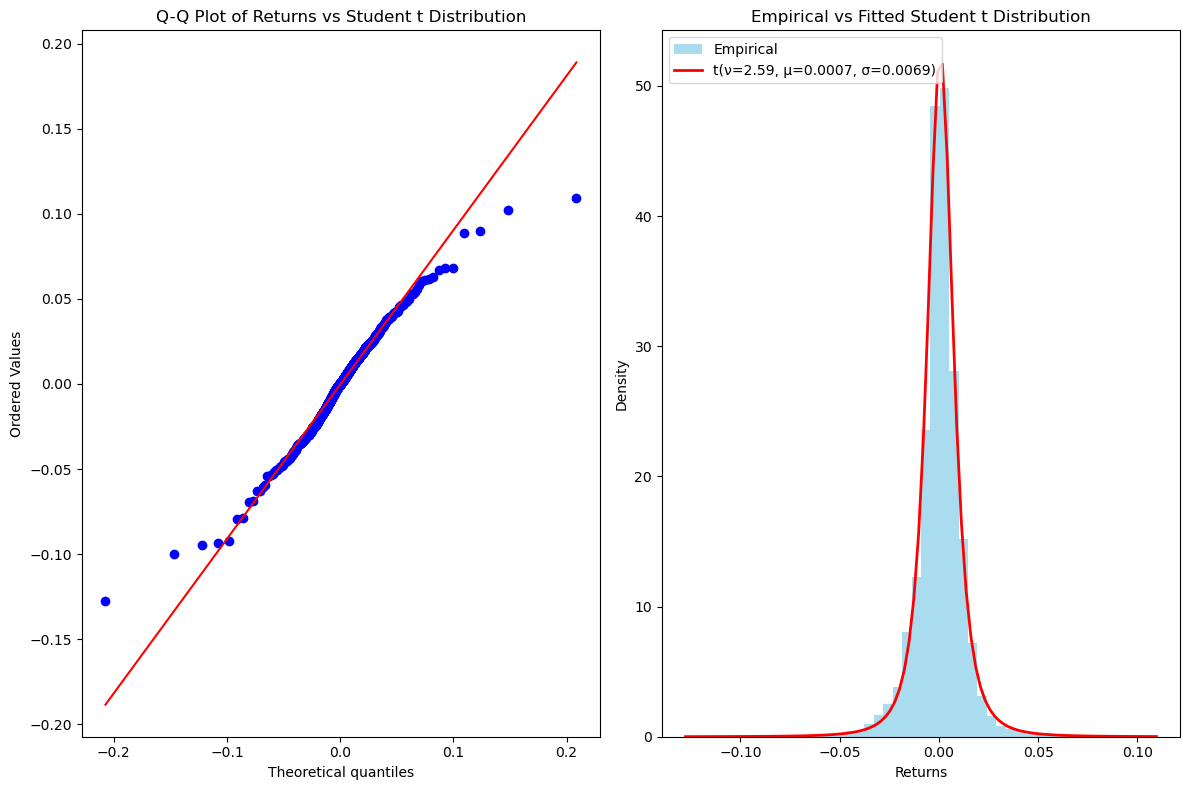


Kolmogorov-Smirnov Test for Student's t Distribution:
Statistic: 0.0185
p-value: 3.1440e-02

Kolmogorov-Smirnov Test (Unstandardized):
Statistic: 0.0185
p-value: 3.1440e-02


In [6]:
# Fit Student's t Distribution and Check Goodness of Fit
params = stats.t.fit(spx['Returns'].dropna())  # Returns nu (df), mu (location) and sigma (scale) parameters
nu, mu, sigma = params  # Returns nu (df), mu (location) and sigma (scale) parameters

# Create visualization
plt.figure(figsize=(12, 8))

# Left subplot: Q-Q plot
plt.subplot(1, 2, 1)
# Create Q-Q plot comparing empirical quantiles with theoretical t distribution quantiles
stats.probplot(spx['Returns'].dropna(), dist=stats.t, sparams=params, plot=plt)
plt.title('Q-Q Plot of Returns vs Student t Distribution')

# Right subplot: Compare fitted t distribution with empirical distribution
plt.subplot(1, 2, 2)
x = np.linspace(spx['Returns'].min(), spx['Returns'].max(), 100)
plt.hist(spx['Returns'].dropna(), bins=50, density=True, alpha=0.7, color='skyblue', label='Empirical')
plt.plot(x, stats.t.pdf(x, *params), 'r-', lw=2, 
         label=f't(ν={nu:.2f}, μ={mu:.4f}, σ={sigma:.4f})')
plt.title('Empirical vs Fitted Student t Distribution')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.savefig('spx_t_fit.pdf', format='pdf')
plt.show()

# Perform Kolmogorov-Smirnov test for t distribution fit
# First standardize the data to use with KS test
standardized_returns = (spx['Returns'].dropna() - mu) / sigma
ks_stat, ks_pvalue = stats.kstest(standardized_returns, 't', args=(nu,))

print("\nKolmogorov-Smirnov Test for Student's t Distribution:")
print(f"Statistic: {ks_stat:.4f}")
print(f"p-value: {ks_pvalue:.4e}")

# Perform KS test on unstandardized data with location and scale parameters
ks_stat_unstd, ks_pvalue_unstd = stats.kstest(spx['Returns'].dropna(), 't', args=(nu, mu, sigma))

print("\nKolmogorov-Smirnov Test (Unstandardized):")
print(f"Statistic: {ks_stat_unstd:.4f}") 
print(f"p-value: {ks_pvalue_unstd:.4e}")





Fitted Normal Inverse Gaussian parameters:
μ (location): 0.0011
α (tail heaviness): 0.3777
β (asymmetry): -0.0455
δ (scale): 0.0073


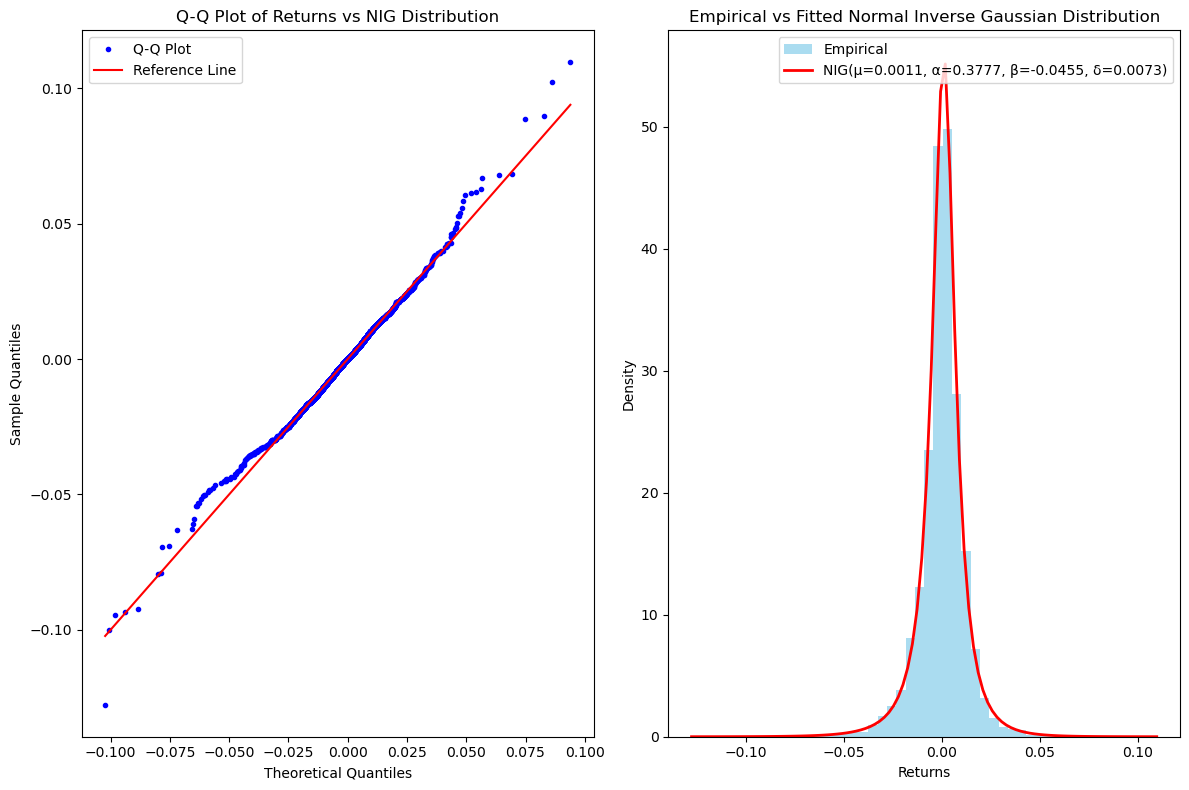


Kolmogorov-Smirnov Test for Normal Inverse Gaussian Distribution:
Statistic: 0.0117
p-value: 3.7915e-01


In [7]:
# Fit Normal Inverse Gaussian distribution using scipy.stats
nig = stats.norminvgauss
nig_fit = nig.fit(spx['Returns'].dropna())
alpha, beta, mu, delta = nig_fit
print(f"\nFitted Normal Inverse Gaussian parameters:")
print(f"μ (location): {mu:.4f}")
print(f"α (tail heaviness): {alpha:.4f}") 
print(f"β (asymmetry): {beta:.4f}")
print(f"δ (scale): {delta:.4f}")

# Create visualization
plt.figure(figsize=(12, 8))

# Left subplot: Q-Q plot
plt.subplot(1, 2, 1)
# Generate simulated values from fitted NIG distribution
n_samples = len(spx['Returns'].dropna())
simulated_values = nig.rvs(size=n_samples, *nig_fit)

# Sort both empirical and simulated values
empirical_quantiles = np.sort(spx['Returns'].dropna())
theoretical_quantiles = np.sort(simulated_values)

plt.plot(theoretical_quantiles, empirical_quantiles, 'b.', label='Q-Q Plot')
plt.plot([min(theoretical_quantiles), max(theoretical_quantiles)],
         [min(theoretical_quantiles), max(theoretical_quantiles)], 
         'r-', label='Reference Line')
plt.title('Q-Q Plot of Returns vs NIG Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.legend()

# Right subplot: Compare fitted NIG distribution with empirical distribution
plt.subplot(1, 2, 2)
x = np.linspace(spx['Returns'].min(), spx['Returns'].max(), 100)
plt.hist(spx['Returns'].dropna(), bins=50, density=True, alpha=0.7, color='skyblue', label='Empirical')

# Generate NIG PDF using fitted distribution
fitted_nig = nig(*nig_fit)
plt.plot(x, fitted_nig.pdf(x), 'r-', lw=2,
         label=f'NIG(μ={mu:.4f}, α={alpha:.4f}, β={beta:.4f}, δ={delta:.4f})')
plt.title('Empirical vs Fitted Normal Inverse Gaussian Distribution')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.savefig('spx_nig_fit.pdf', format='pdf')
plt.show()

# Perform Kolmogorov-Smirnov test for NIG distribution fit
ks_stat, ks_pvalue = stats.kstest(spx['Returns'].dropna(), fitted_nig.cdf)

print("\nKolmogorov-Smirnov Test for Normal Inverse Gaussian Distribution:")
print(f"Statistic: {ks_stat:.4f}")
print(f"p-value: {ks_pvalue:.4e}")



Risk Measures for Shorting SPX Position:
--------------------------------------------------
Confidence Level       VaR            CVaR      
--------------------------------------------------


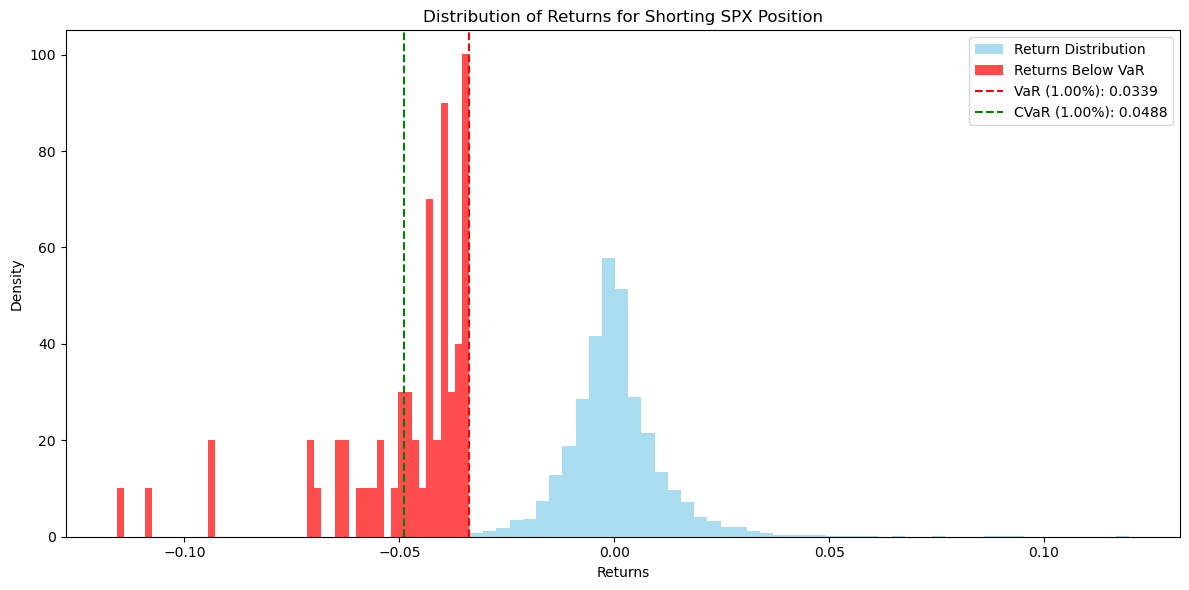

     1.00%          0.0339          0.0488     


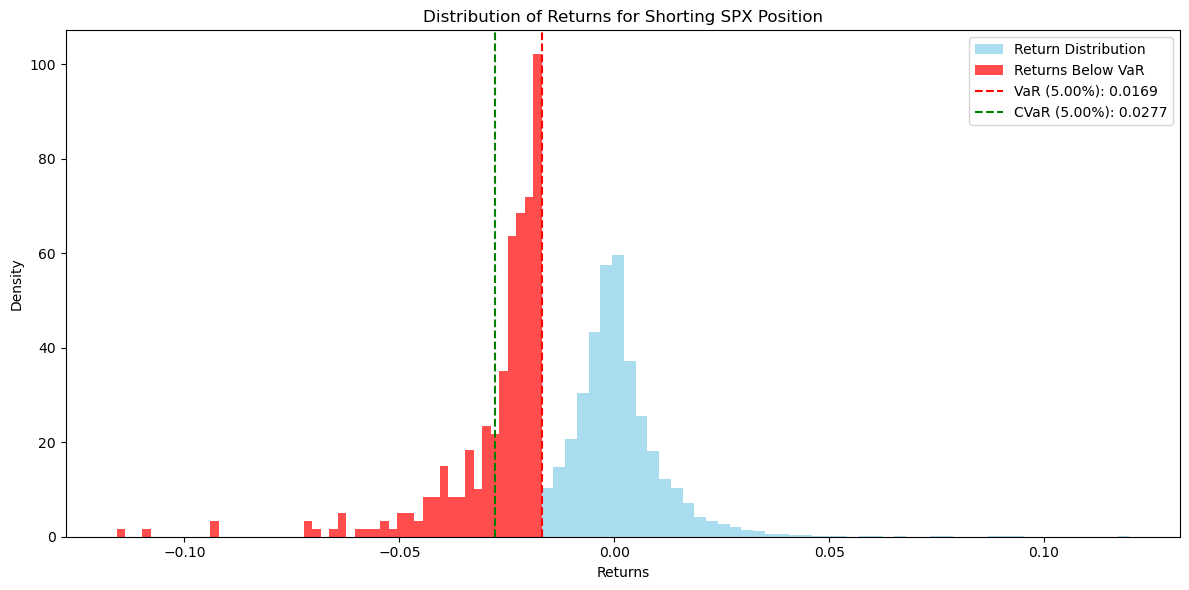

     5.00%          0.0169          0.0277     


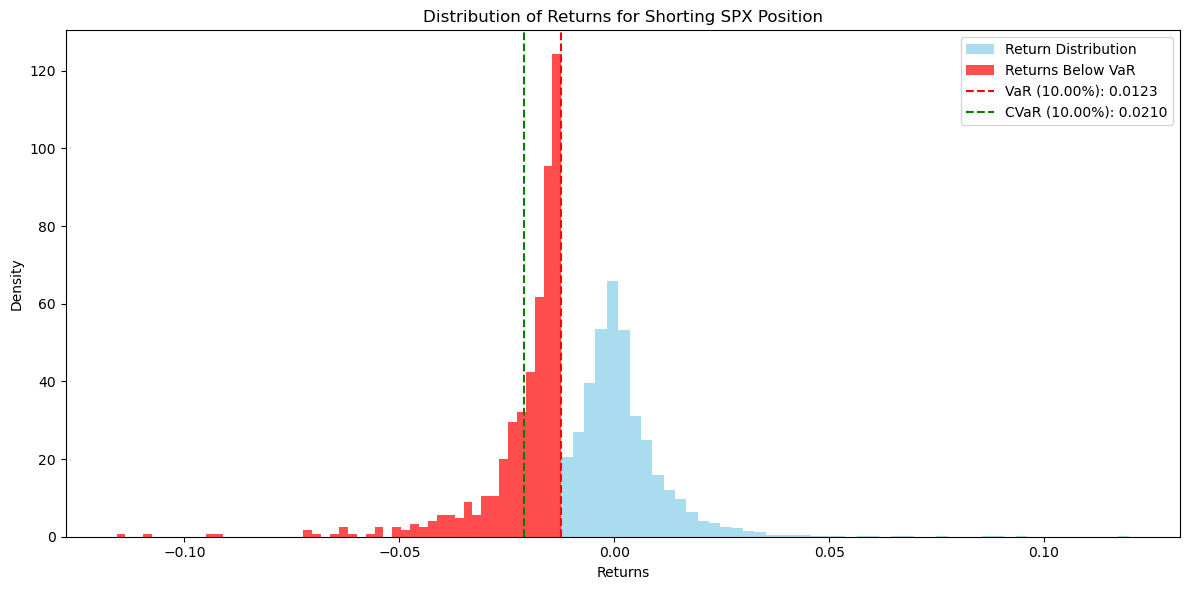

    10.00%          0.0123          0.0210     


In [8]:
# Calculate VaR and CVaR for shorting SPX position
short_returns = 1 - np.exp(spx['Returns'].dropna())
# long_returns = np.exp(spx['Returns'].dropna())-1

# Sort returns in ascending order
sorted_returns = np.sort(short_returns)
T = len(sorted_returns)

# Calculate VaR and CVaR at different confidence levels
confidence_levels = [0.01, 0.05, 0.10]

print("\nRisk Measures for Shorting SPX Position:")
print("-" * 50)
print(f"{'Confidence Level':^15} {'VaR':^15} {'CVaR':^15}")
print("-" * 50)

for alpha in confidence_levels:
    # Calculate index for VaR
    var_idx = int(np.ceil(T * alpha))
    
    # Calculate VaR
    var = -sorted_returns[var_idx-1]
    
    # Calculate CVaR (average of losses beyond VaR)
    cvar = -np.mean(sorted_returns[:var_idx])

    # Visualize VaR and CVaR at 5% confidence level

    plt.figure(figsize=(12, 6))
    plt.hist(short_returns[short_returns > -var], bins=50, density=True, alpha=0.7, color='skyblue', label='Return Distribution')
    plt.hist(short_returns[short_returns <= -var], bins=50, density=True, alpha=0.7, color='red', label='Returns Below VaR')


    # Add vertical lines for VaR and CVaR
    plt.axvline(x=-var, color='red', linestyle='--', label=f'VaR ({alpha:.2%}): {var:.4f}')
    plt.axvline(x=-cvar, color='green', linestyle='--', label=f'CVaR ({alpha:.2%}): {cvar:.4f}')

    plt.title('Distribution of Returns for Shorting SPX Position')
    plt.xlabel('Returns')
    plt.ylabel('Density')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'spx_risk_measures_{alpha}.pdf', format='pdf')
    plt.show()

    print(f"{alpha:^15.2%} {var:^15.4f} {cvar:^15.4f}")

mu_norm: 0.0002529022458810104, sigma_norm: 0.012166051973992004
df: 2.5883810542859047, loc_t: 0.0007040096032750704, scale_t: 0.006914612700140191
alpha_nig: 0.3776817782991834, beta_nig: -0.045487116787650654, mu_nig: 0.0011431853250822611, delta_nig: 0.007339904188529468

Comparison of Risk Measures across Different Methods:
--------------------------------------------------------------------------------
Confidence Level     Method            VaR            CVaR      
--------------------------------------------------------------------------------
     0.10%        Historical        0.0692          0.0887     
     0.10%          Normal          0.0386          0.0397     
     0.10%         Student-t        0.0946          0.1076     
     0.10%            NIG           0.0614          0.0656     
--------------------------------------------------------------------------------
     0.50%        Historical        0.0425          0.0597     
     0.50%          Normal          0.032

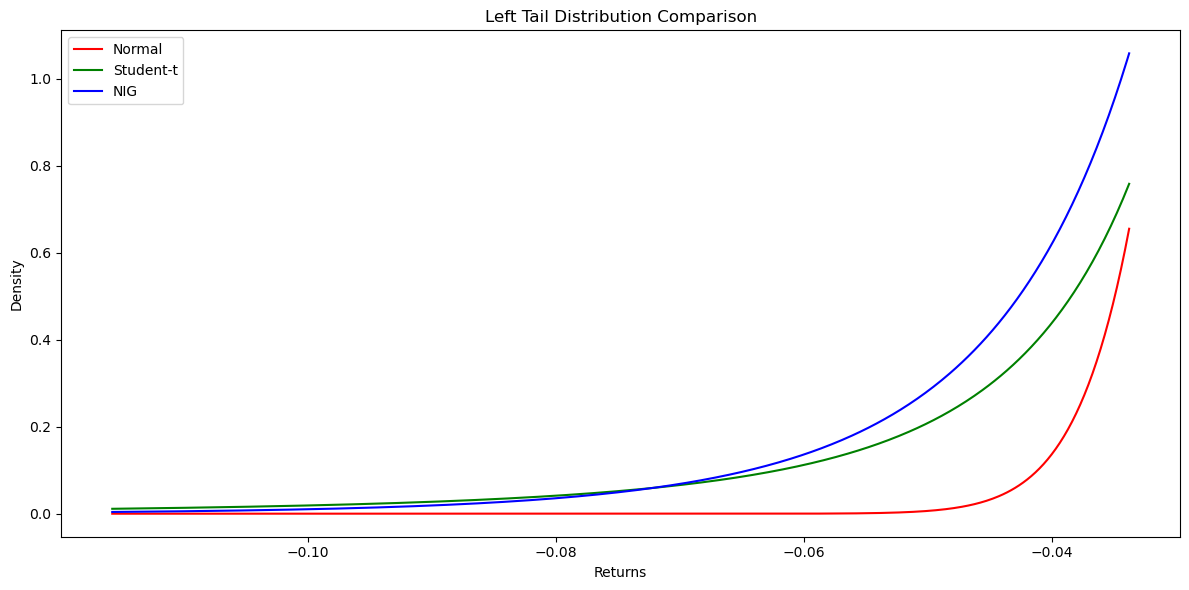

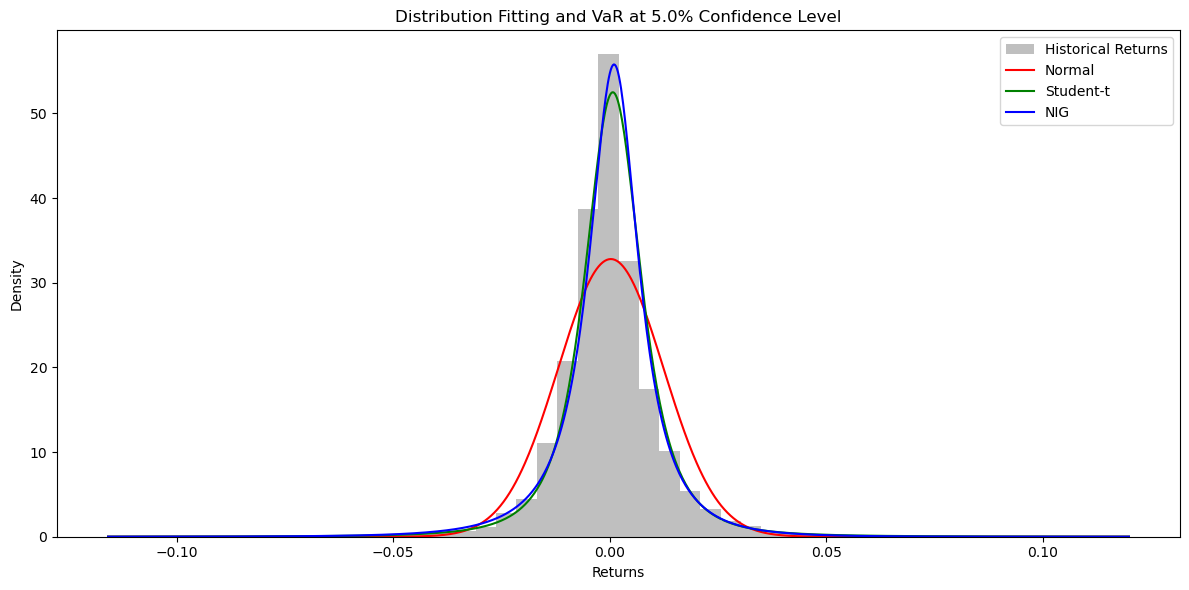

In [10]:
# Estimate VaR and CVaR using fitted distributions
from scipy import stats
from scipy.stats import norm, t, levy_stable
import warnings
warnings.filterwarnings('ignore')

# Get fitted parameters from earlier cells
mu_norm, sigma_norm = stats.norm.fit(spx['Returns'].dropna())
df, loc_t, scale_t = stats.t.fit(spx['Returns'].dropna())
nig_fit = nig.fit(spx['Returns'].dropna())
alpha_nig, beta_nig, mu_nig, delta_nig = nig_fit

print(f"mu_norm: {mu_norm}, sigma_norm: {sigma_norm}")
print(f"df: {df}, loc_t: {loc_t}, scale_t: {scale_t}")
print(f"alpha_nig: {alpha_nig}, beta_nig: {beta_nig}, mu_nig: {mu_nig}, delta_nig: {delta_nig}")
# Function to calculate theoretical VaR and CVaR
def calc_theoretical_risk_measures(dist, alpha, params):
    var = np.exp(dist.ppf(1-alpha, *params))-1
    # var = 1 - np.exp(dist.ppf(alpha, *params)) # for long position
    
    # For CVaR calculation
    n, low = 100, 0.0005
    delta = (alpha-low)/n
    x = np.linspace(low, alpha, n)
    cvar = np.sum((np.exp(dist.ppf(1-x, *params))-1))*delta/(alpha-low)
    # cvar = np.sum(1-np.exp(dist.ppf(x, *params)))*delta/(alpha-low) # for long position
    
    return var, cvar

# Calculate risk measures for each distribution
print("\nComparison of Risk Measures across Different Methods:")
print("-" * 80)
print(f"{'Confidence Level':^15} {'Method':^15} {'VaR':^15} {'CVaR':^15}")
print("-" * 80)


confidence_levels = [0.001, 0.005, 0.01, 0.05]

for alpha in confidence_levels:
    # Historical Simulation (already calculated)
    var_idx = int(np.ceil(T * alpha))
    var_hist = -sorted_returns[var_idx-1]
    cvar_hist = -np.mean(sorted_returns[:var_idx])
    
    # Normal Distribution
    var_norm, cvar_norm = calc_theoretical_risk_measures(norm, alpha, (mu_norm, sigma_norm))
    
    # Student's t Distribution
    var_t, cvar_t = calc_theoretical_risk_measures(t, alpha, (df, loc_t, scale_t))
    
    # NIG Distribution
    var_nig, cvar_nig = calc_theoretical_risk_measures(nig, alpha, (alpha_nig, beta_nig, mu_nig, delta_nig))
    
    # Print results
    methods = ['Historical', 'Normal', 'Student-t', 'NIG']
    vars = [var_hist, var_norm, var_t, var_nig]
    cvars = [cvar_hist, cvar_norm, cvar_t, cvar_nig]
    
    for method, var, cvar in zip(methods, vars, cvars):
        print(f"{alpha:^15.2%} {method:^15} {var:^15.4f} {cvar:^15.4f}")
    print("-" * 80)


# Create a zoomed plot focusing on the left tail
plt.figure(figsize=(12, 6))

# Calculate the left tail threshold based on empirical quantile
tail_threshold = np.quantile(short_returns, 0.01)  # Focus on the lowest 10% of returns

# Filter data for the tail region
tail_mask = short_returns <= tail_threshold
tail_returns = short_returns[tail_mask]

# Plot fitted distributions for the tail region
x_tail = np.linspace(min(short_returns), tail_threshold, 500)
plt.plot(x_tail, norm.pdf(x_tail, mu_norm, sigma_norm), 'r-', label='Normal')
plt.plot(x_tail, t.pdf(x_tail, df, loc_t, scale_t), 'g-', label='Student-t')
plt.plot(x_tail, nig.pdf(x_tail, alpha_nig, beta_nig, mu_nig, delta_nig), 'b-', label='NIG')

plt.title(f'Left Tail Distribution Comparison')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.savefig('tail_distribution_comparison_0.01.pdf', format='pdf')
plt.show()

# Visualize comparison for each confidence level
plt.figure(figsize=(12, 6))

# Plot histogram of returns
plt.hist(short_returns, bins=50, density=True, alpha=0.5, color='gray', label='Historical Returns')
    
    # Plot fitted distributions
x = np.linspace(min(short_returns), max(short_returns), 1000)
plt.plot(x, norm.pdf(x, mu_norm, sigma_norm), 'r-', label='Normal')
plt.plot(x, t.pdf(x, df, loc_t, scale_t), 'g-', label='Student-t')
plt.plot(x, nig.pdf(x, alpha_nig, beta_nig, mu_nig, delta_nig), 'b-', label='NIG')

plt.title(f'Distribution Fitting and VaR at {alpha:.1%} Confidence Level')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.savefig(f'distribution_comparison_{alpha}.pdf', format='pdf')
plt.show()
